In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import helper_fn
import importlib

importlib.reload(helper_fn)

from helper_fn import (
    load_data,
    give_monthly_sales_data,
    give_monthly_sales_data_customer_level,
    train_prophet_with_params,
    evaluate,
    plot_results,
)


from itertools import product

In [2]:
df_path = "../../../data/France/processed_data/combined_df.csv"

df_sellin, df_sellout = load_data(df_path)

## City Level Monthly Prediction Only (FMC)

In [3]:
df_sellout_monthly_level = give_monthly_sales_data(df_sellout)
df_sellout_monthly_level = df_sellout_monthly_level[1:]

In [4]:
df_sellout_monthly_level.head()

,year_month,sales_quantity
1,2026-01-01,707294.0
2,2026-02-01,680484.0
3,2026-03-01,734402.0


In [5]:
df = df_sellout_monthly_level.copy()
df["year_month"] = pd.to_datetime(df["year_month"])
df = df.sort_values("year_month")
df["month_name"] = df["year_month"].dt.strftime("%b")
next_month_date = df["year_month"].max() + pd.DateOffset(months=1)
next_month_label = next_month_date.strftime("%b")

##### Predict using moving averages

SMA Forecast: 707393.3333333334


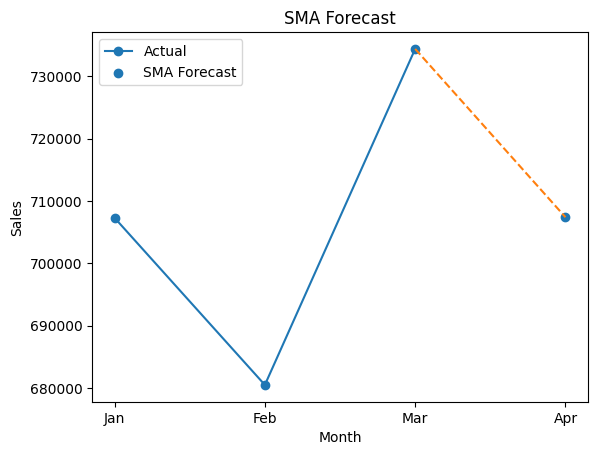

In [6]:
sma_forecast = df["sales_quantity"].mean()
print("SMA Forecast:", sma_forecast)


plt.figure()

# X values
x_labels = list(df["month_name"]) + [next_month_label]

# Y values
y_actual = list(df["sales_quantity"])
y_full = y_actual + [sma_forecast]

plt.plot(x_labels[:-1], y_actual, marker="o", label="Actual")
plt.plot(x_labels[-2:], y_full[-2:], linestyle="dashed")
plt.scatter(next_month_label, sma_forecast, label="SMA Forecast")

plt.title("SMA Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.show()

##### Predict Using Linear Regression

Trend Forecast: 734501.3333333335


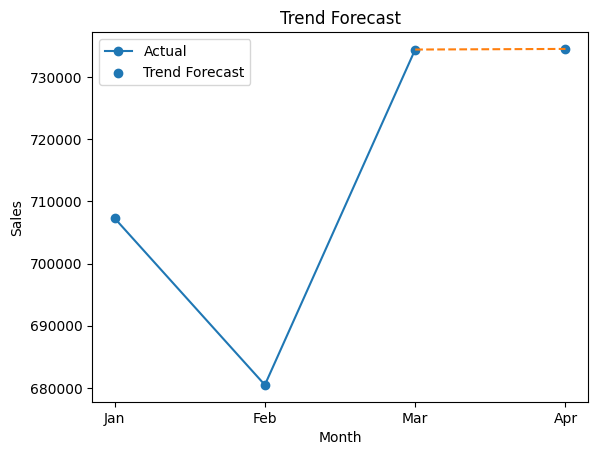

In [7]:
y = df["sales_quantity"].values
x = np.arange(len(y))

coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

trend_forecast = trend(len(y))
print("Trend Forecast:", trend_forecast)

plt.figure()

x_labels = list(df["month_name"]) + [next_month_label]
y_actual = list(df["sales_quantity"])
y_full = y_actual + [trend_forecast]

plt.plot(x_labels[:-1], y_actual, marker="o", label="Actual")
plt.plot(x_labels[-2:], y_full[-2:], linestyle="dashed")
plt.scatter(next_month_label, trend_forecast, label="Trend Forecast")

plt.title("Trend Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.show()

##### Weighted Prediction

Weighted Avg Forecast: 711911.3333333333


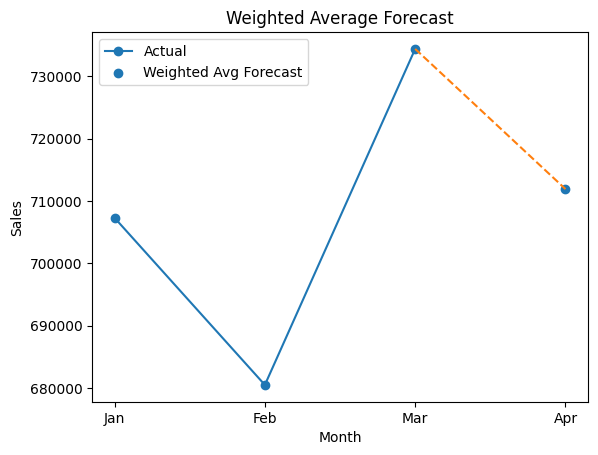

In [8]:
weights = np.linspace(1, len(df), len(df))
weights = weights / weights.sum()

wa_forecast = (df["sales_quantity"] * weights).sum()
print("Weighted Avg Forecast:", wa_forecast)

plt.figure()

x_labels = list(df["month_name"]) + [next_month_label]
y_actual = list(df["sales_quantity"])
y_full = y_actual + [wa_forecast]

plt.plot(x_labels[:-1], y_actual, marker="o", label="Actual")
plt.plot(x_labels[-2:], y_full[-2:], linestyle="dashed")
plt.scatter(next_month_label, wa_forecast, label="Weighted Avg Forecast")

plt.title("Weighted Average Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.show()

## Monthly Sales Customer Level (FMC)

In [9]:
df_monthly = give_monthly_sales_data_customer_level(df_sellout, "0011t000011b1ovAAA")
df = df_monthly.copy()
df = df.sort_values("year_month").reset_index(drop=True)
df["month_label"] = df["year_month"].dt.strftime("%b")

In [10]:
df.head()

,year_month,sales_quantity,month_label
0,2026-01-01,1642.0,Jan
1,2026-02-01,1480.0,Feb
2,2026-03-01,1552.0,Mar


##### Weighted Moving Averages

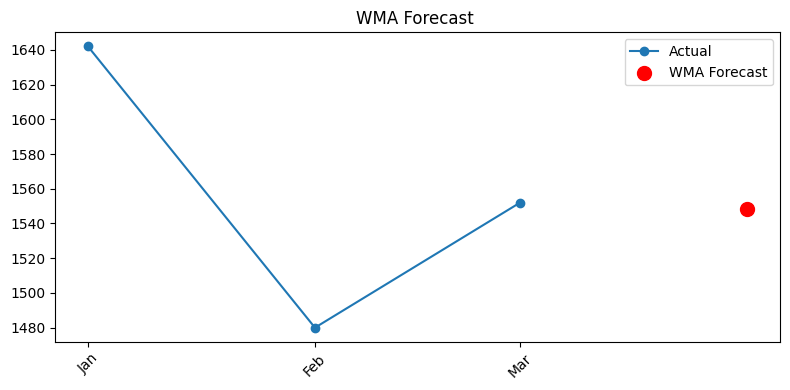

In [11]:
weights = np.array([0.2, 0.3, 0.5])
last_3 = df["sales_quantity"].iloc[-3:].values
wma_forecast = np.dot(last_3, weights)
wma_forecast

next_month = df["year_month"].max() + pd.DateOffset(months=1)
plt.figure(figsize=(8, 4))
plt.plot(df["year_month"], df["sales_quantity"], marker="o", label="Actual")
plt.scatter(next_month, wma_forecast, color="red", s=100, label="WMA Forecast")
plt.xticks(df["year_month"], df["month_label"], rotation=45)
plt.title(f"WMA Forecast ")
plt.legend()
plt.tight_layout()
plt.show()

##### Exponential Moving Averages

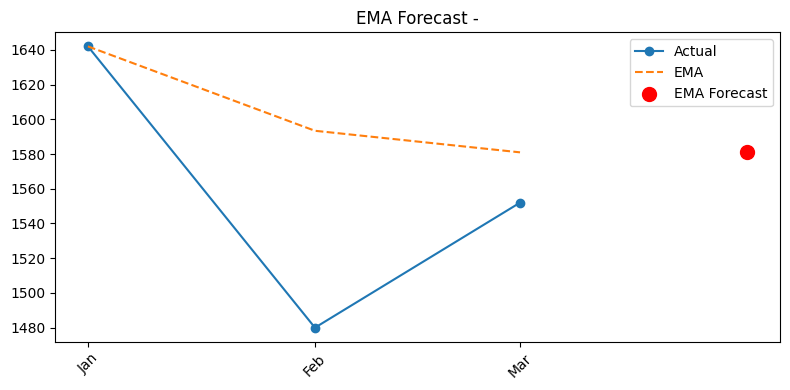

In [12]:
alpha = 0.3

df["ema"] = df["sales_quantity"].ewm(alpha=alpha, adjust=False).mean()

ema_forecast = df["ema"].iloc[-1]

ema_forecast

next_month = df["year_month"].max() + pd.DateOffset(months=1)

plt.figure(figsize=(8, 4))

plt.plot(df["year_month"], df["sales_quantity"], marker="o", label="Actual")
plt.plot(df["year_month"], df["ema"], linestyle="--", label="EMA")

plt.scatter(next_month, ema_forecast, color="red", s=100, label="EMA Forecast")

plt.xticks(df["year_month"], df["month_label"], rotation=45)

plt.title(f"EMA Forecast -")
plt.legend()
plt.tight_layout()
plt.show()

/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


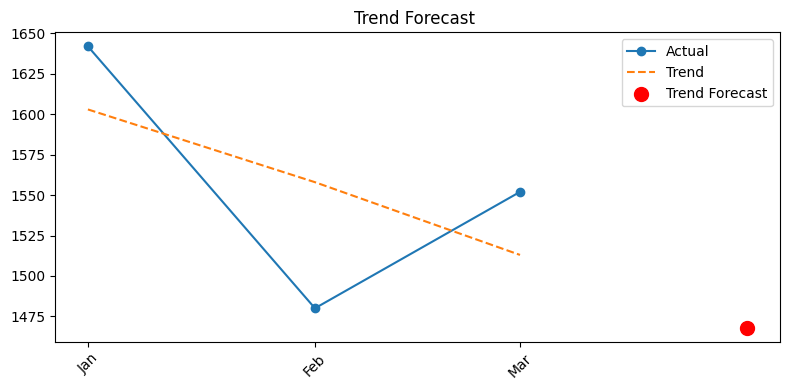

In [13]:
from sklearn.linear_model import LinearRegression

df["t"] = np.arange(len(df))

model = LinearRegression()
model.fit(df[["t"]], df["sales_quantity"])

trend_forecast = model.predict([[len(df)]])[0]

trend_forecast

next_month = df["year_month"].max() + pd.DateOffset(months=1)

df["trend"] = model.predict(df[["t"]])

plt.figure(figsize=(8, 4))

plt.plot(df["year_month"], df["sales_quantity"], marker="o", label="Actual")
plt.plot(df["year_month"], df["trend"], linestyle="--", label="Trend")

plt.scatter(next_month, trend_forecast, color="red", s=100, label="Trend Forecast")

plt.xticks(df["year_month"], df["month_label"], rotation=45)

plt.title(f"Trend Forecast ")
plt.legend()
plt.tight_layout()
plt.show()

##### Prophet

In [14]:
from prophet import Prophet

df_prophet = df[["year_month", "sales_quantity"]].copy()

df_prophet = df_prophet.rename(columns={"year_month": "ds", "sales_quantity": "y"})

12:26:00 - cmdstanpy - INFO - Chain [1] start processing
12:26:00 - cmdstanpy - INFO - Chain [1] done processing


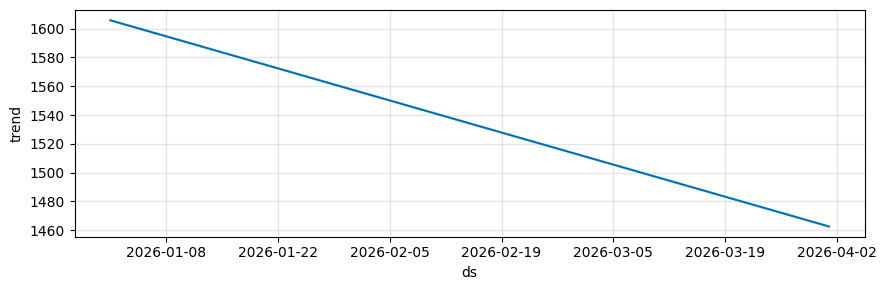

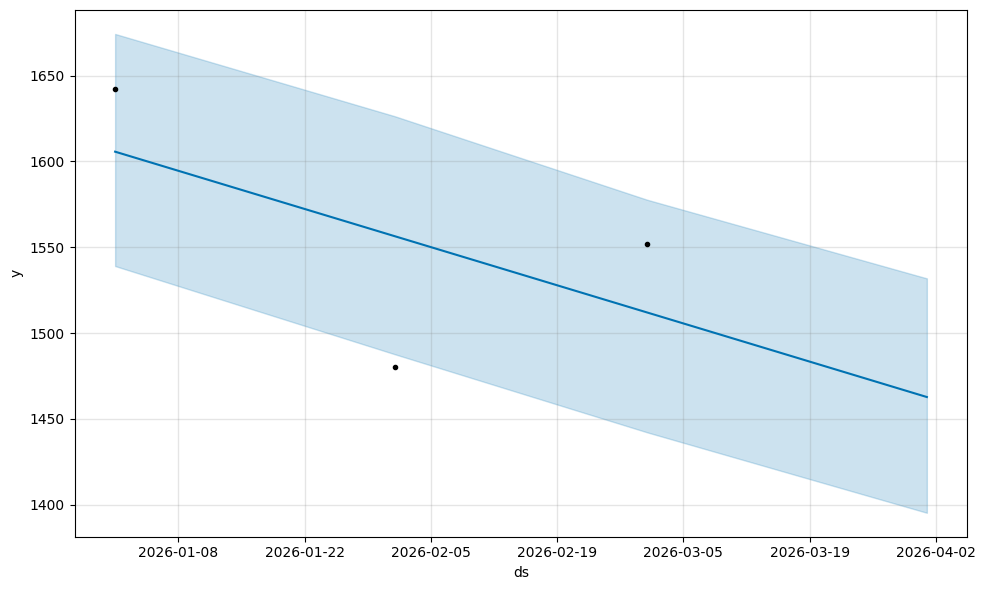

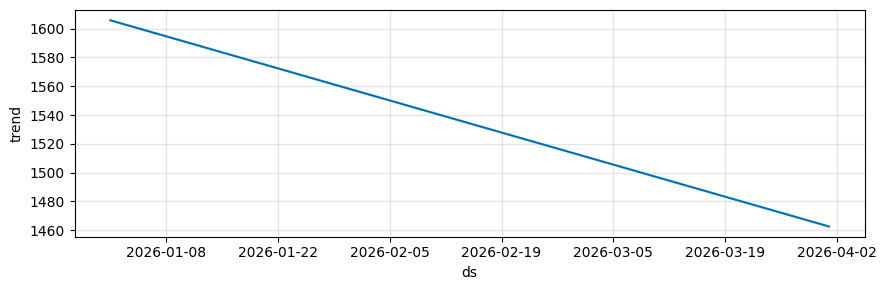

In [15]:
model_p = Prophet()

model_p.fit(df_prophet)
future = model_p.make_future_dataframe(periods=1, freq="MS")

forecast = model_p.predict(future)

prophet_forecast = forecast.iloc[-1]["yhat"]

prophet_forecast


# plot models.
model_p.plot(forecast)

model_p.plot_components(forecast)

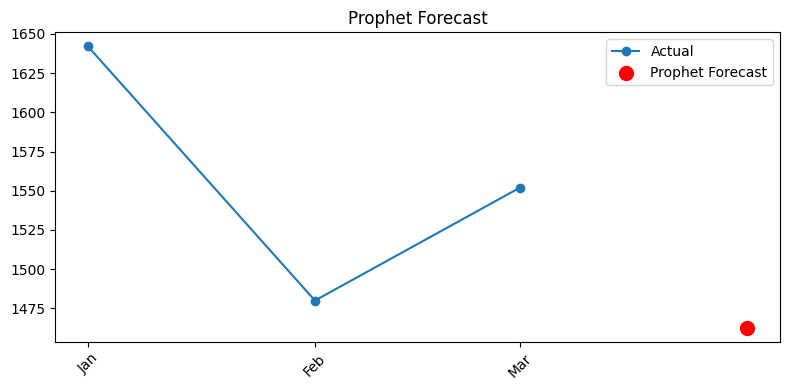

In [16]:
next_month = df["year_month"].max() + pd.DateOffset(months=1)

plt.figure(figsize=(8, 4))

plt.plot(df["year_month"], df["sales_quantity"], marker="o", label="Actual")

plt.scatter(next_month, prophet_forecast, color="red", s=100, label="Prophet Forecast")

plt.xticks(df["year_month"], df["month_label"], rotation=45)

plt.title(f"Prophet Forecast")
plt.legend()
plt.tight_layout()
plt.show()

## Final Part

In [17]:
def selected_data(df, customer_code, sku_code, include_sku=False):

    if include_sku:
        df_daily = df[
            (df["customer_code"] == customer_code) & (df["sku_code"] == sku_code)
        ].copy()

    else:
        df_daily = df[df["customer_code"] == customer_code].copy()

    df_daily = df_daily.groupby("date", as_index=False)["sales_quantity"].sum()

    # full date range
    full_dates = pd.date_range(df_daily["date"].min(), df_daily["date"].max(), freq="D")

    # reindex to full range
    df_daily = (
        df_daily.set_index("date")
        .reindex(full_dates)
        .fillna(0)
        .rename_axis("date")
        .reset_index()
    )

    df_daily["sales_quantity"] = df_daily["sales_quantity"].astype(float)

    return df_daily

In [18]:
# 0011t000011bBO8AAM -> SKU a0U1t000002PXloEAG
# ['0011t000011b2rGAAQ',
#  '0011t000011b4Q4AAI',
#  '0011t000011b61MAAQ',
#  '0011t000011b62DAAQ',
#  '0011t000011bBO8AAM']
df_selected_si = selected_data(
    df_sellin, "0011t000011b1ovAAA", "a0U1t000002PXjmEAG", include_sku=False
)
df_selected_so = selected_data(
    df_sellout, "0011t000011b1ovAAA", "a0U1t000002PXjmEAG", include_sku=False
)

In [19]:
df_selected_si

,date,sales_quantity
0,2026-01-05,1376.0
1,2026-01-06,0.0
2,2026-01-07,0.0
3,2026-01-08,0.0
4,2026-01-09,0.0
...,...,...
77,2026-03-23,0.0
78,2026-03-24,0.0
79,2026-03-25,56.0
80,2026-03-26,0.0


##### Prophet without anything

12:26:05 - cmdstanpy - INFO - Chain [1] start processing


          ds       y
0 2026-01-05  1376.0
1 2026-01-06     0.0
2 2026-01-07     0.0
3 2026-01-08     0.0
4 2026-01-09     0.0


12:26:05 - cmdstanpy - INFO - Chain [1] done processing


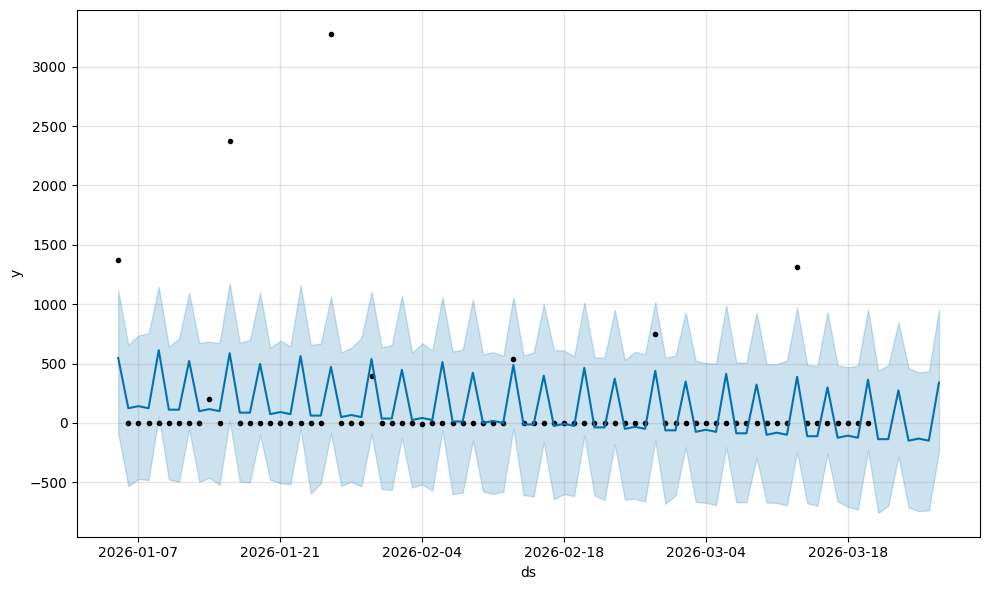

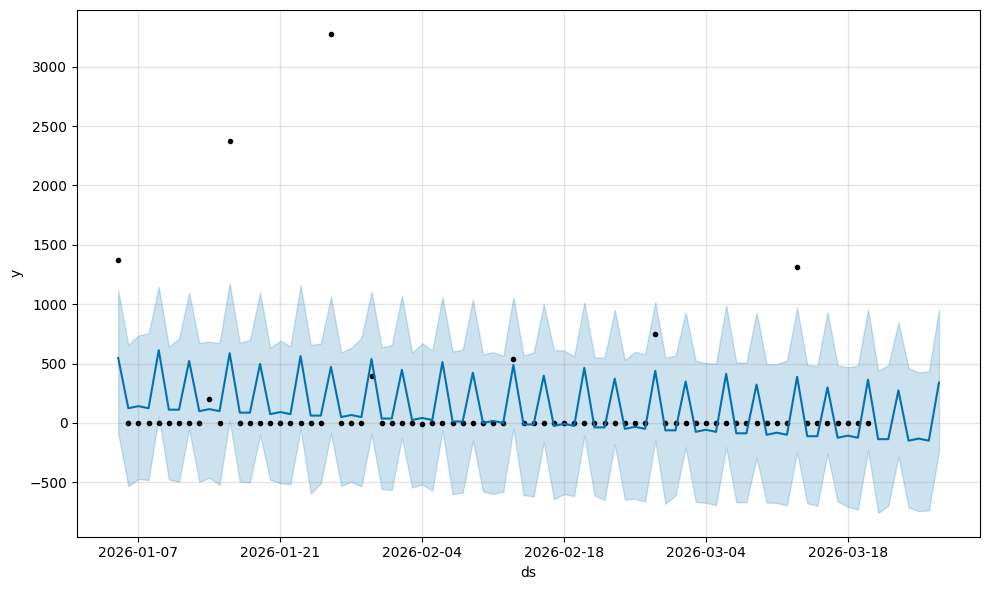

In [20]:
df = df_selected_si.copy()
df_prophet = df.rename(columns={"date": "ds", "sales_quantity": "y"})

print(df_prophet.head())

train = df_prophet.iloc[:-7].copy()
test = df_prophet.iloc[-7:].copy()

model = Prophet(
    daily_seasonality=True, yearly_seasonality=False, weekly_seasonality=True
)

model.fit(train)


future = model.make_future_dataframe(periods=7, freq="D")
forecast = model.predict(future)

pred_test = forecast[["ds", "yhat"]].tail(7)

result = test.merge(pred_test, on="ds", how="left")
result.columns = ["date", "actual", "predicted"]

model.plot(forecast)

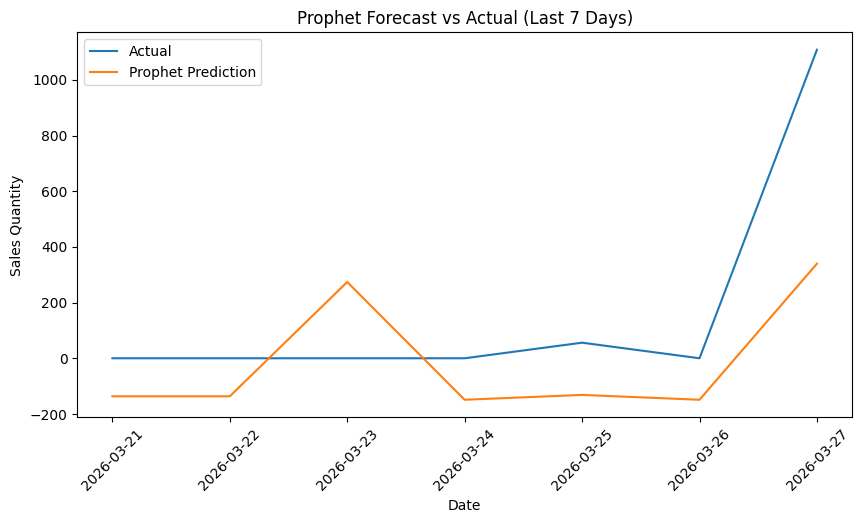

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(result["date"], result["actual"], label="Actual")
plt.plot(result["date"], result["predicted"], label="Prophet Prediction")

plt.title("Prophet Forecast vs Actual (Last 7 Days)")
plt.xlabel("Date")
plt.ylabel("Sales Quantity")
plt.legend()

plt.xticks(rotation=45)
plt.show()

##### Predict the next visit date using d/t method. 

In [22]:
df = df_selected_si.copy()
df["event"] = (df["sales_quantity"] > 0).astype(int)

df["dayofweek"] = df["date"].dt.dayofweek
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month

# lag feature (VERY IMPORTANT for event prediction)
df["prev_event"] = df["event"].shift(1).fillna(0)
df["prev_2_event"] = df["event"].shift(2).fillna(0)

In [23]:
train = df.iloc[:-10]
test = df.iloc[-10:]

In [24]:
from sklearn.linear_model import LogisticRegression

features = ["dayofweek", "day", "month", "prev_event", "prev_2_event"]

X_train = train[features]
y_train = train["event"]

X_test = test[features]
y_test = test["event"]

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
test = test.copy()
test["event_prob"] = model.predict_proba(X_test)[:, 1]
test["event_pred"] = (test["event_prob"] > 0.5).astype(int)

In [26]:
test[["date", "sales_quantity", "event", "event_prob", "event_pred"]]

,date,sales_quantity,event,event_prob,event_pred
72,2026-03-18,0.0,0,0.078508,0
73,2026-03-19,0.0,0,0.077780,0
74,2026-03-20,0.0,0,0.077059,0
75,2026-03-21,0.0,0,0.076344,0
76,2026-03-22,0.0,0,0.075635,0
77,2026-03-23,0.0,0,0.109471,0
78,2026-03-24,0.0,0,0.108490,0
79,2026-03-25,56.0,1,0.107517,0
80,2026-03-26,0.0,0,0.056988,0
81,2026-03-27,1108.0,1,0.112659,0


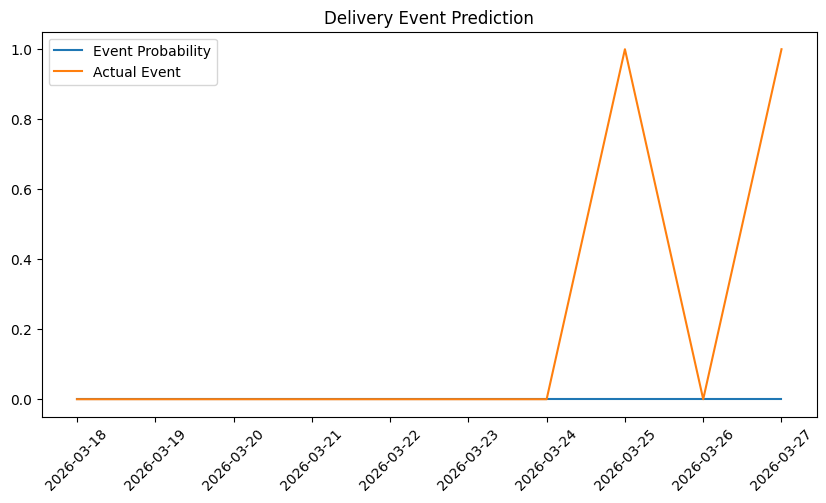

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(test["date"], test["event_pred"], label="Event Probability")
plt.plot(test["date"], test["event"], label="Actual Event")

plt.legend()
plt.xticks(rotation=45)
plt.title("Delivery Event Prediction")
plt.show()

##### Inter Arrive Time Delivery

In [28]:
df = df_selected_si.copy()
df["date"] = pd.to_datetime(df["date"])

df = df.groupby("date", as_index=False)["sales_quantity"].sum()

event_dates = df[df["sales_quantity"] > 0]["date"].sort_values().reset_index(drop=True)

In [29]:
train_events = event_dates.iloc[:-1]
test_event = event_dates.iloc[-1]

train_events, test_event

(0   2026-01-05
 1   2026-01-14
 2   2026-01-16
 3   2026-01-26
 4   2026-01-30
 5   2026-02-13
 6   2026-02-27
 7   2026-03-13
 8   2026-03-25
 Name: date, dtype: datetime64[ns],
 Timestamp('2026-03-27 00:00:00'))

In [30]:
train_gaps = train_events.diff().dt.days.dropna()

gap_df = pd.DataFrame(
    {"event_date": train_events[1:].values, "gap_days": train_gaps.values}
)

gap_df

,event_date,gap_days
0,2026-01-14,9.0
1,2026-01-16,2.0
2,2026-01-26,10.0
3,2026-01-30,4.0
4,2026-02-13,14.0
5,2026-02-27,14.0
6,2026-03-13,14.0
7,2026-03-25,12.0


In [31]:
avg_gap = gap_df["gap_days"].mean()

last_train_event = train_events.iloc[-1]

predicted_date_avg = last_train_event + pd.Timedelta(days=int(round(avg_gap)))

predicted_date_avg

Timestamp('2026-04-04 00:00:00')

In [32]:
from sklearn.linear_model import LinearRegression

gap_df["prev_gap"] = gap_df["gap_days"].shift(1)
gap_df = gap_df.dropna()

X = gap_df[["prev_gap"]]
y = gap_df["gap_days"]

model = LinearRegression()
model.fit(X, y)

last_gap = gap_df["gap_days"].iloc[-1]
pred_gap = model.predict([[last_gap]])[0]

predicted_date_ml = last_train_event + pd.Timedelta(days=int(round(pred_gap)))

predicted_date_ml

/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Timestamp('2026-04-04 00:00:00')

In [33]:
result = pd.DataFrame(
    {
        "method": ["Average Gap", "ML Model"],
        "predicted_date": [predicted_date_avg, predicted_date_ml],
        "actual_date": [test_event, test_event],
    }
)

result

,method,predicted_date,actual_date
0,Average Gap,2026-04-04,2026-03-27
1,ML Model,2026-04-04,2026-03-27


In [34]:
result["error_days"] = (result["predicted_date"] - result["actual_date"]).dt.days

result

,method,predicted_date,actual_date,error_days
0,Average Gap,2026-04-04,2026-03-27,8
1,ML Model,2026-04-04,2026-03-27,8


##### Prophet with all features

In [35]:
df = df_selected_si.copy()

In [36]:
df["y"] = np.where(
    df["sales_quantity"] > 0, np.log1p(df["sales_quantity"]), 0  # compress spikes
)

/home/asad/anaconda3/envs/footfall_explorer/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [37]:
from prophet import Prophet

df_prophet = df.rename(columns={"date": "ds", "y": "y"})

In [38]:
train = df_prophet.iloc[:-7]
test = df_prophet.iloc[-7:]

In [39]:
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=0.1,
)

model.fit(train)

future = model.make_future_dataframe(periods=7, freq="D")
forecast = model.predict(future)

12:26:21 - cmdstanpy - INFO - Chain [1] start processing
12:26:21 - cmdstanpy - INFO - Chain [1] done processing


In [40]:
pred = forecast[["ds", "yhat"]].tail(7).copy()

# invert log1p approx
pred["yhat"] = np.expm1(pred["yhat"])

In [41]:
result = test[["ds", "sales_quantity"]].merge(pred, on="ds", how="left")

result.columns = ["date", "actual", "predicted"]

# If value is > 5, then 1 else 0.
result["predicted_"] = np.where(result["predicted"] > 5, 1, 0)  # Previously 5
result["actual_"] = np.where(result["actual"] > 1, 1, 0)

result

,date,actual,predicted,predicted_,actual_
0,2026-03-21,0.0,-0.436720,0,0
1,2026-03-22,0.0,-0.436720,0,0
2,2026-03-23,0.0,1.152787,0,0
3,2026-03-24,0.0,-0.465359,0,0
4,2026-03-25,56.0,-0.134153,0,1
5,2026-03-26,0.0,-0.465359,0,0
6,2026-03-27,1108.0,10.607887,1,1


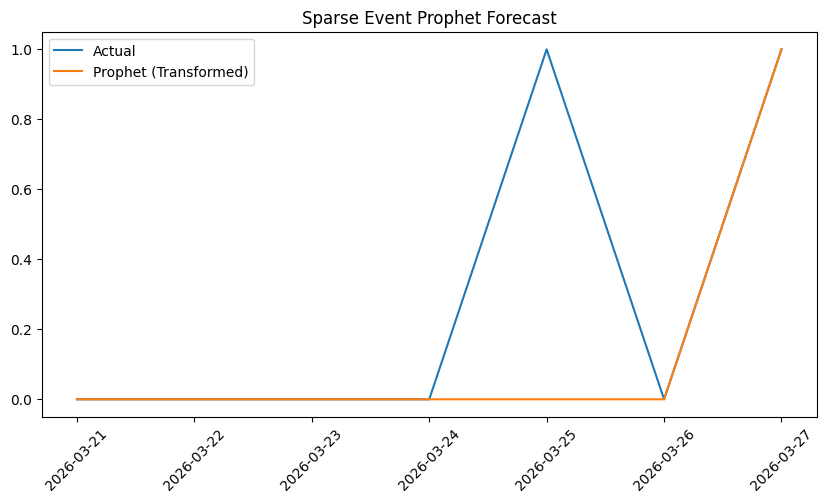

In [42]:
plt.figure(figsize=(10, 5))

plt.plot(result["date"], result["actual_"], label="Actual")
plt.plot(result["date"], result["predicted_"], label="Prophet (Transformed)")

plt.title("Sparse Event Prophet Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.show()

- Do it for sales out now

In [92]:
min_test_date_si = test.ds.max()

print(min_test_date_si)

# Select the so data from this min date.
df_selected_so

2026-03-27 00:00:00


,ds,y
0,2026-01-02,348.0
1,2026-01-03,395.0
2,2026-01-04,0.0
3,2026-01-05,528.0
4,2026-01-06,382.0
...,...,...
84,2026-03-27,591.0
85,2026-03-28,422.0
86,2026-03-29,0.0
87,2026-03-30,534.0


In [ ]:
# Sir for example, the sellin has data from 1st Jan 2026 to 26 March 2026 and for the same customer, we have only data from 1st Jan to 25 Jan in sell out.

##### Prophet for Sell Out

In [86]:
df_selected_so.columns = ["ds", "y"]

X_train_so = df_selected_so[:-7]
X_test_so = df_selected_so[-7:]

In [87]:
param_grid = {
    "changepoint_prior_scale": [0.01, 0.1, 0.5],
    "seasonality_prior_scale": [1.0, 5.0, 10.0],
    "seasonality_mode": ["additive", "multiplicative"],
}

all_params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

13:11:23 - cmdstanpy - INFO - Chain [1] start processing
13:11:23 - cmdstanpy - INFO - Chain [1] done processing
13:11:24 - cmdstanpy - INFO - Chain [1] start processing
13:11:24 - cmdstanpy - INFO - Chain [1] done processing
13:11:24 - cmdstanpy - INFO - Chain [1] start processing
13:11:24 - cmdstanpy - INFO - Chain [1] done processing
13:11:24 - cmdstanpy - INFO - Chain [1] start processing
13:11:24 - cmdstanpy - INFO - Chain [1] done processing
13:11:24 - cmdstanpy - INFO - Chain [1] start processing
13:11:25 - cmdstanpy - INFO - Chain [1] done processing
13:11:25 - cmdstanpy - INFO - Chain [1] start processing
13:11:25 - cmdstanpy - INFO - Chain [1] done processing
13:11:25 - cmdstanpy - INFO - Chain [1] start processing
13:11:25 - cmdstanpy - INFO - Chain [1] done processing
13:11:25 - cmdstanpy - INFO - Chain [1] start processing
13:11:26 - cmdstanpy - INFO - Chain [1] done processing
13:11:26 - cmdstanpy - INFO - Chain [1] start processing
13:11:26 - cmdstanpy - INFO - Chain [1]

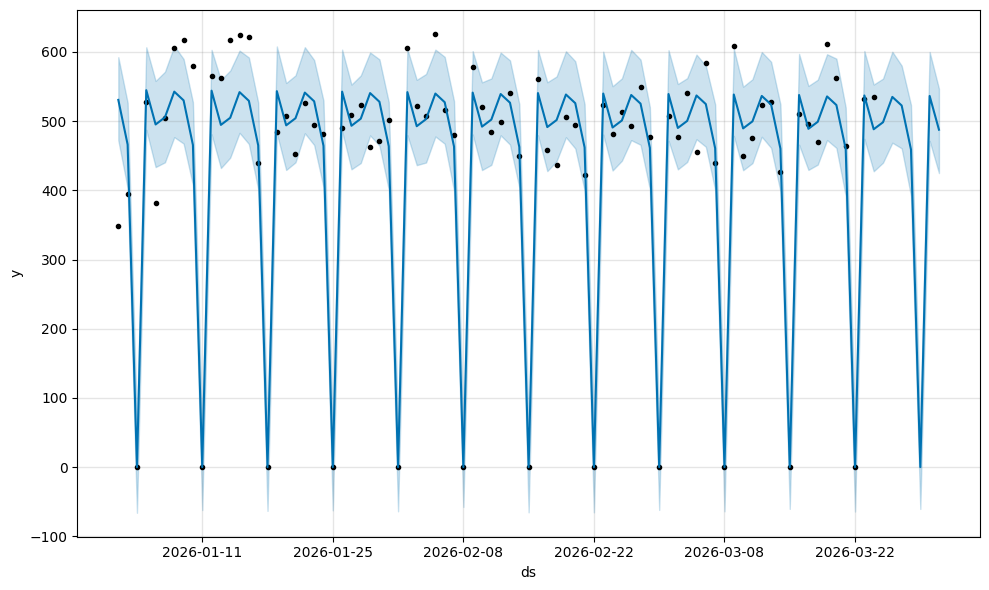

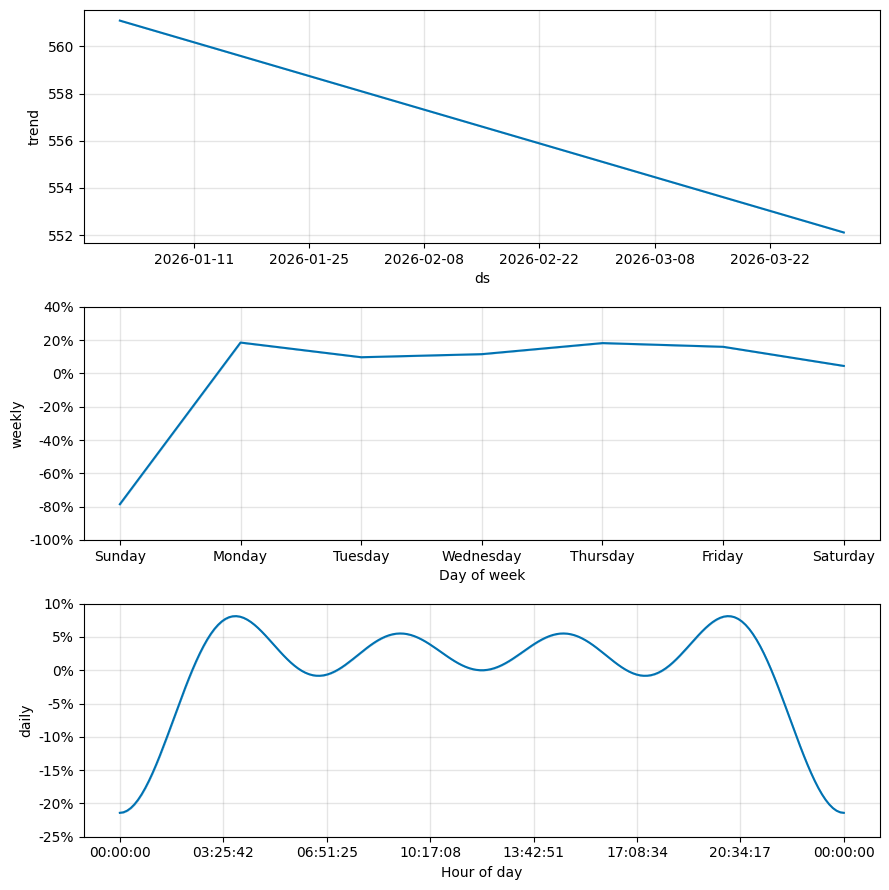

In [ ]:
result_list = []

best_score = float("inf")
best_params = None
best_model = None
best_forecast = None
best_eval_df = None


for param in all_params:
    model = train_prophet_with_params(X_train_so, param, add_holidays=False)

    future = model.make_future_dataframe(periods=len(X_test_so), freq="D")
    forecast = model.predict(future)

    result, eval_df = evaluate(forecast=forecast, df_test=X_test_so)

    result_list.append(
        {
            **param,
            "MAE": result["MAE"],
            "MAPE": result["MAPE"],
            "RMSE": result["RMSE"],
        }
    )

    if result["MAE"] < best_score:
        best_score = result["MAE"]
        best_params = param
        best_model = model
        best_forecast = forecast
        best_eval_df = eval_df

if best_model is not None:
    best_model.plot(best_forecast)
    best_model.plot_components(best_forecast)

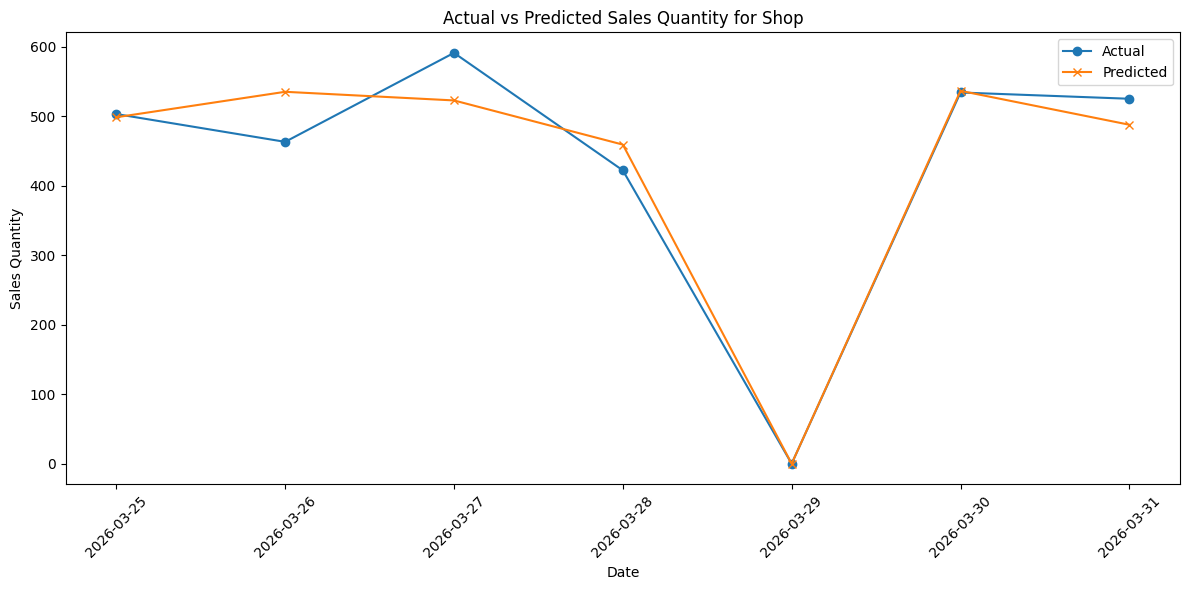

In [91]:
plot_results(best_eval_df)

##### Check the prophet model. 

In [44]:
from prediction.prophet_predict import ProphetPredict

ModuleNotFoundError: No module named 'prediction'

In [387]:
def get_customers_with_low_difference(
    sellin_df: pd.DataFrame, sellout_df: pd.DataFrame, threshold: float = 0.02
) -> list:

    # 1. Aggregate sellin
    sellin_agg = (
        sellin_df.groupby("customer_code")["sales_quantity"]
        .sum()
        .reset_index()
        .rename(columns={"sales_quantity": "sellin"})
    )

    # 2. Aggregate sellout
    sellout_agg = (
        sellout_df.groupby("customer_code")["sales_quantity"]
        .sum()
        .reset_index()
        .rename(columns={"sales_quantity": "sellout"})
    )

    # 3. Merge both
    df = pd.merge(sellin_agg, sellout_agg, on="customer_code", how="inner")

    # 4. Compute percentage difference
    df["sellin_safe"] = df["sellin"].replace(0, np.nan)

    df["percent_diff"] = (df["sellout"] - df["sellin"]).abs() / df["sellin_safe"]

    # 5. Handle zero sellin cases
    df["percent_diff"] = df["percent_diff"].fillna(
        df["sellout"].apply(lambda x: 1 if x > 0 else 0)
    )

    # 6. Filter customers
    result = df[df["percent_diff"] <= threshold]["customer_code"].tolist()

    return result

In [388]:
get_customers_with_low_difference(df_sellin, df_sellout, threshold=0.4)

['0011t000011b2rGAAQ',
 '0011t000011b56IAAQ',
 '0011t000011b58wAAA',
 '0011t000011b62DAAQ',
 '0011t000011bCpXAAU']

In [43]:
df_sellout[df_sellout["customer_code"] == "0011t000011b2rGAAQ"][
    "sales_quantity"
].sum(), df_sellin[df_sellin["customer_code"] == "0011t000011b2rGAAQ"][
    "sales_quantity"
].sum()

(12882.0, 11656.0)

In [317]:
temp = df_sellout[df_sellout["customer_code"] == "0011t000011bCpXAAU"]

temp[temp["category"] == "FMC"]["sku_code"].unique()

array(['a0U1t000002PXloEAG', 'a0U1t000002PXjoEAG', 'a0U1t000002PXlYEAW',
       'a0U1t000002PXlqEAG', 'a0U1t000002PXpcEAG', 'a0U1t000002PXkQEAW',
       'a0U1t000002PXjpEAG', 'a0U3W000002BYaXUAW', 'a0U3W000002BYaWUAW',
       'a0U1t000002PXjmEAG', 'a0U1t000002PXovEAG', 'a0U1t000002PXnYEAW',
       'a0U1t000002PXjuEAG', 'a0U1t000002PXpKEAW', 'a0U1t000002PXjhEAG',
       'a0U1t000002PXpUEAW', 'a0U1t000002PXkJEAW', 'a0U1t000002PXpzEAG',
       'a0U1t000002PXn1EAG', 'a0U1t000002PXq9EAG', 'a0U1t000002PXn3EAG',
       'a0U1t000002PXkTEAW', 'a0U3W000000TPMmUAO', 'a0U1t000002PXk2EAG',
       'a0U1t000002PXn4EAG', 'a0U1t000002PXnSEAW', 'a0U3W000002BYagUAG',
       'a0U1t000002PXpqEAG', 'a0U1t000002PXqGEAW'], dtype=object)